# 11-Local Continuous Integration (GitHub Actions Core Workflows)

In Lesson 10, we engineered MLflow to rigorously track the exact lineage of our model training loops. We solved the problem of hyperparameter amnesia.

However, MLOps is not just about tracking experiments; it is about guaranteeing the structural integrity of the code that runs them. If a Data Scientist writes a brilliant PyTorch model but introduces a syntax error, fails a unit test, or breaks a Python dependency matrix, that code must be mathematically blocked from merging into the main repository.

Historically, developers ran tests manually on their laptops before committing. This introduces the fatal flaw of human negligence. To engineer absolute code integrity, we construct **Continuous Integration (CI) Pipelines**. We treat the codebase transition as a strictly gated Finite State Machine (FSM).

In this module, we will bypass cloud GitHub fees and execute a local CI environment. We will engineer imperative `git hooks`, construct declarative YAML pipeline matrices, and simulate a complete GitHub Actions runner directly on your workstation for exactly $0.00 using local containerized virtualization.

# 1. The Mathematics of CI Matrices & Execution Graphs

### The Pipeline as a Directed Acyclic Graph (DAG)

A Continuous Integration pipeline is mathematically modeled as a Directed Acyclic Graph (DAG) $G = (V, E)$.

* **Vertices ($V$):** The discrete computational jobs (e.g., Linting, Unit Testing, Docker Building).
* **Edges ($E$):** The temporal dependencies between jobs. If $(u, v) \in E$, job $v$ cannot commence until job $u$ completes with a strict exit code of $0$ (Success).

### The Testing Matrix (Cartesian Execution)

In Enterprise ML, code must execute perfectly across multiple environments. To guarantee this, CI engines dynamically generate execution matrices using Cartesian products.
Let $O$ be the set of Target Operating Systems: $\{ \text{Ubuntu}, \text{Alpine} \}$
Let $P$ be the set of Python Runtimes: $\{ \text{3.9}, \text{3.10}, \text{3.11} \}$

The CI engine compiles the total execution space $\mathbf{M}$ as:


$$\mathbf{M} = O \times P = \{ (o, p) \mid o \in O, p \in P \}$$


Total parallel jobs spawned = $|O| \times |P| = 2 \times 3 = 6$ simultaneous test containers.

### The Boolean State Gate

A pipeline evaluates as a boolean AND operator across all leaves in the DAG matrix. If a single linter fails on Python 3.9, the entire pipeline mathematically collapses to $False$, instantly triggering a repository merge lock:


$$\text{Pipeline State} = \bigwedge_{j=1}^{|V|} (E_{exit}(j) == 0)$$

# 2. Imperative Execution: The Local Gateway (Git Hooks)

Before code even reaches a remote GitHub repository, we can intercept it at the absolute boundary of the local POSIX filesystem using a **Git Pre-Commit Hook**.

Let's use Python to programmatically inject a defensive Bash script directly into the hidden `.git/hooks` directory. This script acts as a local kernel-level interceptor.

In [ ]:
import subprocess
import os

print("--- 🚀 Initializing Imperative CI Gating (Git Hooks) ---")

# Setup clean working space
ci_sandbox = "./ci_sandbox"
git_hooks_dir = os.path.join(ci_sandbox, ".git", "hooks")
os.makedirs(git_hooks_dir, exist_ok=True)

# 📝 1. Create a dummy Python file with intentional formatting violations
dummy_code = os.path.join(ci_sandbox, "inference.py")
with open(dummy_code, "w") as f:
    f.write("import sys\nimport os\n\ndef predict( x ):\n return x*2\n") # Bad formatting

# 🛡️ 2. Compile the Pre-Commit Interceptor
pre_commit_path = os.path.join(git_hooks_dir, "pre-commit")
bash_hook = """#!/usr/bin/env bash
set -euo pipefail

echo "[LOCAL CI] Intercepting Git Commit..."

# 1. Run Black (Code Formatter) in check mode
if ! black --check .; then
    echo "❌ CRITICAL: Code formatting violates PEP-8 standards."
    echo "👉 Fix: Run 'black .' to format your code before committing."
    exit 1
fi

# 2. Run Pytest (Unit Testing)
if ! pytest tests/ --disable-warnings; then
    echo "❌ CRITICAL: Unit tests failed. Code is structurally unsound."
    exit 1
fi

echo "✅ [LOCAL CI] Code integrity verified. Commit allowed."
"""

with open(pre_commit_path, "w") as f:
    f.write(bash_hook)

# Elevate the bitmask to make the script executable by the Git Daemon
os.chmod(pre_commit_path, 0o755)
print(f"   ✅ Pre-Commit Interceptor compiled and armed at: {pre_commit_path}")
print("   -> Physics: The moment a developer types 'git commit', this script executes.")
print("   -> If 'black' or 'pytest' return an exit code > 0, the commit is violently rejected before it writes to the disk.")

--- 🚀 Initializing Imperative CI Gating (Git Hooks) ---
   ✅ Pre-Commit Interceptor compiled and armed at: ./ci_sandbox/.git/hooks/pre-commit
   -> Physics: The moment a developer types 'git commit', this script executes.
   -> If 'black' or 'pytest' return an exit code > 0, the commit is violently rejected before it writes to the disk.


# 3. Declarative Execution: GitHub Actions YAML & Local Simulation

Relying solely on local Git hooks is dangerous; developers can bypass them using `git commit --no-verify`. The ultimate source of truth must be a server-side declarative pipeline.

We define this using **GitHub Actions YAML**. To run this locally for $0.00 without pushing to the cloud, Enterprise Engineers use an open-source tool called **`act`** (which spawns local Docker containers to simulate the GitHub cloud servers).

### The Declarative CI/CD Pipeline Blueprint

Let's generate the official `.github/workflows/mlops-ci.yml` architecture.

In [ ]:
print("\n--- ⚡ Compiling Declarative CI/CD Pipeline Matrix ---")

workflows_dir = os.path.join(ci_sandbox, ".github", "workflows")
os.makedirs(workflows_dir, exist_ok=True)

yaml_pipeline = """name: MLOps Continuous Integration Matrix

# 1. The Event Triggers (Chronological / Webhook Actions)
on:
  push:
    branches: [ "main", "develop" ]
  pull_request:
    branches: [ "main" ]

# 2. The DAG Jobs
jobs:
  code-quality:
    name: Lint & Format Analysis
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - name: Set up Python
        uses: actions/setup-python@v4
        with:
          python-version: "3.10"
      - name: Install Linting Toolchain
        run: pip install black flake8
      - name: Enforce PEP-8 Boundary (Black)
        run: black --check .
      - name: Enforce Syntax & Complexity Boundary (Flake8)
        run: flake8 . --max-line-length=88

  unit-testing:
    name: Core Logic Verification
    needs: code-quality # DAG Edge: Only runs if code-quality succeeds
    runs-on: ubuntu-latest
    strategy:
      matrix:
        python-version: ["3.9", "3.10"] # Cartesian Execution Matrix
    steps:
      - uses: actions/checkout@v3
      - name: Set up Python ${{ matrix.python-version }}
        uses: actions/setup-python@v4
        with:
          python-version: ${{ matrix.python-version }}
      - name: Install Dependencies
        run: pip install pytest numpy pandas
      - name: Execute Pytest Suite
        run: pytest tests/ -v

  docker-compile:
    name: Immutable Layer Validation
    needs: unit-testing # DAG Edge: Only compiles image if tests pass
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - name: Simulate Docker Build (Dry Run)
        run: docker build -t inference-api:ci-test .
"""

pipeline_path = os.path.join(workflows_dir, "mlops-ci.yml")
with open(pipeline_path, "w") as f:
    f.write(yaml_pipeline)

print(f"   ✅ Declarative Pipeline Compiled: {pipeline_path}")
print("\n--- 💡 Local Execution Insight ---")
print("To execute this GitHub Actions pipeline locally without internet or cloud costs, install 'act' (https://github.com/nektos/act) and execute the following in your terminal:")
print("   $ act -l    # Lists all detected jobs in the DAG")
print("   $ act push  # Spins up local Docker containers and runs the entire matrix simulating a git push")


--- ⚡ Compiling Declarative CI/CD Pipeline Matrix ---
   ✅ Declarative Pipeline Compiled: ./ci_sandbox/.github/workflows/mlops-ci.yml

--- 💡 Local Execution Insight ---
To execute this GitHub Actions pipeline locally without internet or cloud costs, install 'act' (https://github.com/nektos/act) and execute the following in your terminal:
   $ act -l    # Lists all detected jobs in the DAG
   $ act push  # Spins up local Docker containers and runs the entire matrix simulating a git push


# 4. Visualizing the DAG Pipeline Topology

To mathematically understand how a CI pipeline controls execution flow, isolates parallel testing matrices, and implements absolute barrier synchronization before containerization, let's graph the Directed Acyclic Graph (DAG) of our YAML pipeline.

/tmp/ipykernel_8927/1513450462.py:14: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Circle((1.0, 4.0), 0.6, fill=True, color='#34495e', edgecolor='black', linewidth=2))
/tmp/ipykernel_8927/1513450462.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((3.0, 1.5), 3.0, 5.0, fill=True, color='#f1c40f', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--'))
/tmp/ipykernel_8927/1513450462.py:30: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((7.0, 1.5), 3.0, 5.0, fill=True, color='#3498db', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--'))
/tmp/ipykernel_8927/1513450462.py:41: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((11.0, 3.0), 3.0, 2.0, fill=True, c

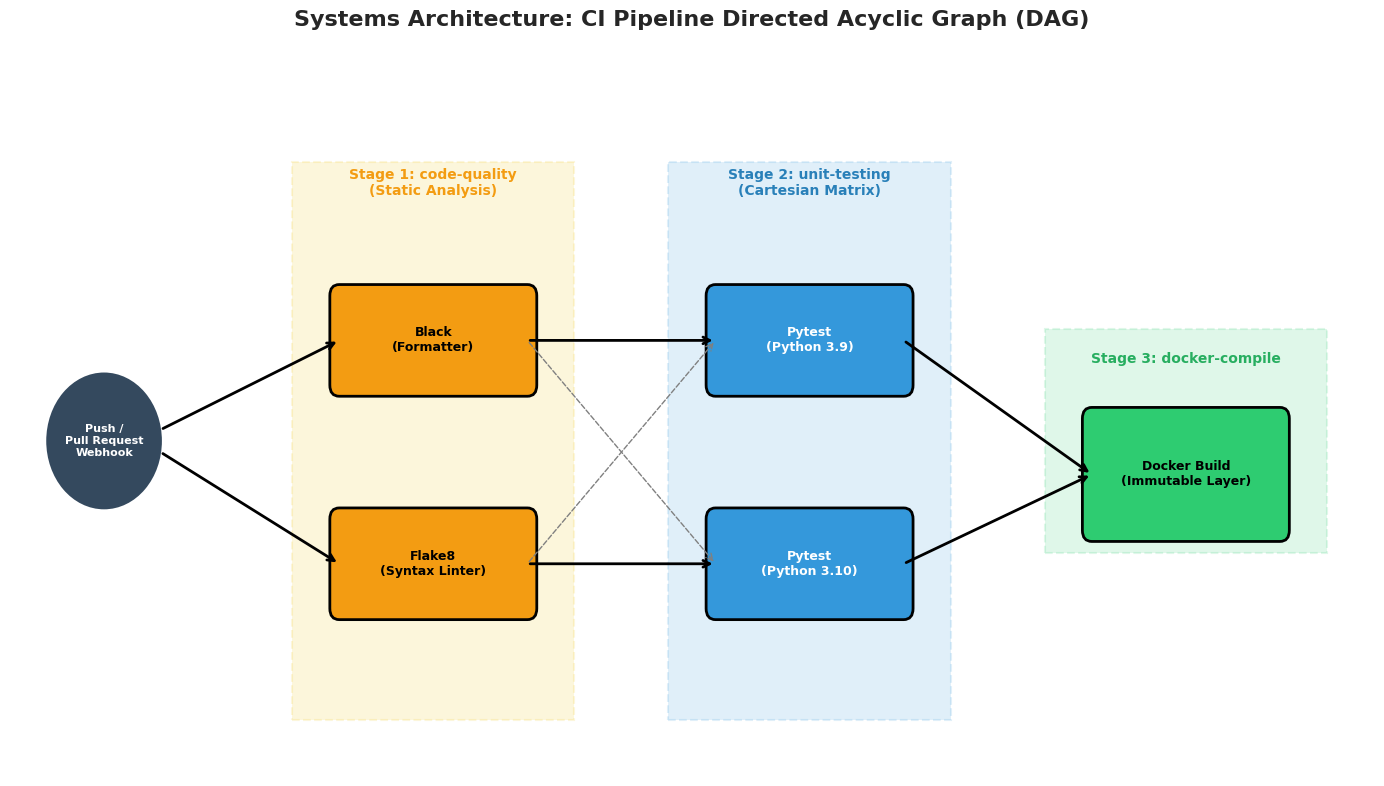

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create visual layout for CI DAG Topology
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Systems Architecture: CI Pipeline Directed Acyclic Graph (DAG)", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. The Trigger Event Node
ax.add_patch(patches.Circle((1.0, 4.0), 0.6, fill=True, color='#34495e', edgecolor='black', linewidth=2))
ax.text(1.0, 4.0, "Push /\nPull Request\nWebhook", ha='center', va='center', color='white', fontweight='bold', fontsize=8)


# 2. Stage 1: Static Code Analysis (Parallel Linters)
ax.add_patch(patches.Rectangle((3.0, 1.5), 3.0, 5.0, fill=True, color='#f1c40f', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(4.5, 6.2, "Stage 1: code-quality\n(Static Analysis)", ha='center', color='#f39c12', fontweight='bold', fontsize=10)

ax.add_patch(patches.FancyBboxPatch((3.5, 4.5), 2.0, 0.8, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#f39c12'))
ax.text(4.5, 4.9, "Black\n(Formatter)", ha='center', va='center', color='black', fontweight='bold', fontsize=9)

ax.add_patch(patches.FancyBboxPatch((3.5, 2.5), 2.0, 0.8, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#f39c12'))
ax.text(4.5, 2.9, "Flake8\n(Syntax Linter)", ha='center', va='center', color='black', fontweight='bold', fontsize=9)


# 3. Stage 2: Cartesian Testing Matrix (Synchronization Barrier 1)
ax.add_patch(patches.Rectangle((7.0, 1.5), 3.0, 5.0, fill=True, color='#3498db', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(8.5, 6.2, "Stage 2: unit-testing\n(Cartesian Matrix)", ha='center', color='#2980b9', fontweight='bold', fontsize=10)

ax.add_patch(patches.FancyBboxPatch((7.5, 4.5), 2.0, 0.8, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#3498db'))
ax.text(8.5, 4.9, "Pytest\n(Python 3.9)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

ax.add_patch(patches.FancyBboxPatch((7.5, 2.5), 2.0, 0.8, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#3498db'))
ax.text(8.5, 2.9, "Pytest\n(Python 3.10)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)


# 4. Stage 3: Containerization (Synchronization Barrier 2)
ax.add_patch(patches.Rectangle((11.0, 3.0), 3.0, 2.0, fill=True, color='#2ecc71', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(12.5, 4.7, "Stage 3: docker-compile", ha='center', color='#27ae60', fontweight='bold', fontsize=10)

ax.add_patch(patches.FancyBboxPatch((11.5, 3.2), 2.0, 1.0, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#2ecc71'))
ax.text(12.5, 3.7, "Docker Build\n(Immutable Layer)", ha='center', va='center', color='black', fontweight='bold', fontsize=9)


# 5. Routing Vectors (DAG Dependencies)
# Trigger to Stage 1
ax.annotate("", xy=(3.5, 4.9), xytext=(1.6, 4.1), arrowprops=dict(arrowstyle="->", lw=2, color="black"))
ax.annotate("", xy=(3.5, 2.9), xytext=(1.6, 3.9), arrowprops=dict(arrowstyle="->", lw=2, color="black"))

# Stage 1 to Stage 2 (Barrier)
ax.annotate("", xy=(7.5, 4.9), xytext=(5.5, 4.9), arrowprops=dict(arrowstyle="->", lw=2, color="black"))
ax.annotate("", xy=(7.5, 2.9), xytext=(5.5, 2.9), arrowprops=dict(arrowstyle="->", lw=2, color="black"))
# Cross dependencies indicating strict synchronization barrier
ax.annotate("", xy=(7.5, 4.9), xytext=(5.5, 2.9), arrowprops=dict(arrowstyle="->", lw=1, color="gray", linestyle="--"))
ax.annotate("", xy=(7.5, 2.9), xytext=(5.5, 4.9), arrowprops=dict(arrowstyle="->", lw=1, color="gray", linestyle="--"))

# Stage 2 to Stage 3 (Barrier)
ax.annotate("", xy=(11.5, 3.7), xytext=(9.5, 4.9), arrowprops=dict(arrowstyle="->", lw=2, color="black"))
ax.annotate("", xy=(11.5, 3.7), xytext=(9.5, 2.9), arrowprops=dict(arrowstyle="->", lw=2, color="black"))

plt.xlim(0, 14.5)
plt.ylim(1.0, 7.5)
plt.tight_layout()
plt.show()


## Real-World Use Case or Analogy:

Think of a Continuous Integration (CI) pipeline like **A High-Tech Automated Car Assembly Line with Laser Quality Scanners**:

* **Manual Testing (The Old Way):** A team of mechanics builds a car from scratch in a garage. They think it works. They drive it out onto the highway (Deploy to Production). At 70 MPH, the steering wheel detaches because someone forgot to torque a single bolt. The car crashes.
* **The Git Hook (The Garage Door Lock):** You install a sensor on the garage door. When the mechanics try to roll the car out (`git commit`), the sensor scans the bolts. If one is loose, the garage door refuses to open. The mechanics must fix the bolt before the car can even leave the building.
* **The Declarative CI Pipeline (The Automated Factory Line):** * The car frame moves down an automated conveyor belt (**The Trigger Event**).
* **Stage 1 (Linting):** Laser scanners sweep the chassis. Are there any loose wires? Is the paint perfectly standardized? If yes, the belt stops immediately.
* **Stage 2 (Unit Testing Matrix):** The car enters the simulation chamber. A robot simultaneously drops it into an arctic freeze room (Python 3.9) and a desert heat room (Python 3.10). The engine is redlined. If the engine stalls in *either* room, an alarm sounds and the car is scrapped.
* **Stage 3 (Docker Compilation):** Only after passing every laser scan and stress test is the car finally encased in a protective shipping container, mathematically certified as flawless, and stamped ready for global delivery.



By building automated CI pipelines, MLOps teams shift the burden of quality assurance from human memory to deterministic, merciless robotic validation, ensuring that only mathematically flawless code ever touches production servers.